<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Red_Neuronal_Autoencoder_No_Supervisada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
#Importar librerías
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense


In [3]:
#Crear dataset NO supervisado
X, _ = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

X = StandardScaler().fit_transform(X)


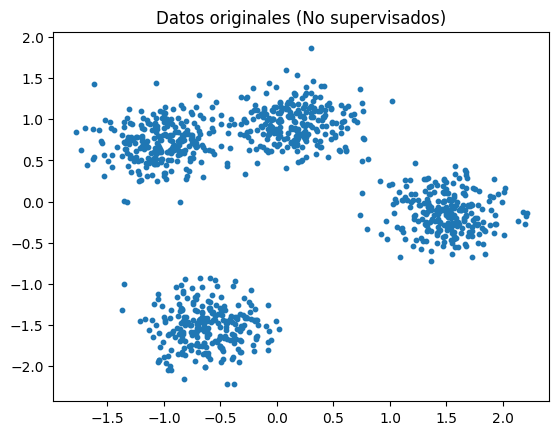

In [4]:
plt.scatter(X[:,0], X[:,1], s=10)
plt.title("Datos originales (No supervisados)")
plt.show()


In [5]:
#Definir el Autoencoder

input_dim = X.shape[1]
latent_dim = 1  # Compresión fuerte

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(4, activation='relu')(input_layer)
latent = Dense(latent_dim, activation='linear')(encoded)

# Decoder
decoded = Dense(4, activation='relu')(latent)
output_layer = Dense(input_dim, activation='linear')(decoded)

# Modelo
autoencoder = Model(input_layer, output_layer)
encoder = Model(input_layer, latent)

#Compilar el modelo
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

In [7]:
#Entrenar (sin etiquetas)

history = autoencoder.fit(
    X, X,
    epochs=50,
    batch_size=32,
    verbose=1
)


Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8815
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8206 
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7516 
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7016 
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6376 
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6362 
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6071 
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5725 
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5494 
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5040 
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4961 
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4726
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4385 
Epoch 14/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4318 
Epoch 15/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4229 
Epoch 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


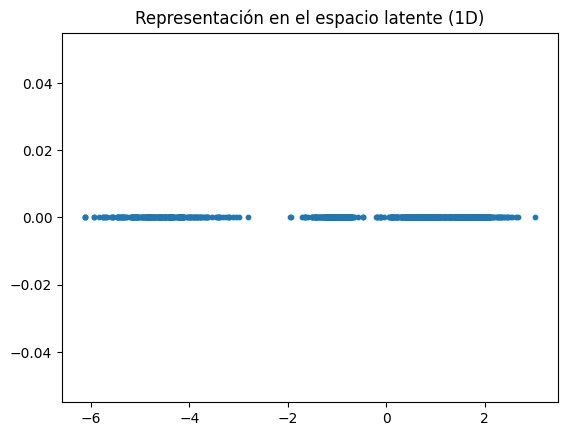

In [8]:
#Espacio latente aprendido

X_latent = encoder.predict(X)

plt.scatter(X_latent, np.zeros_like(X_latent), s=10)
plt.title("Representación en el espacio latente (1D)")
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


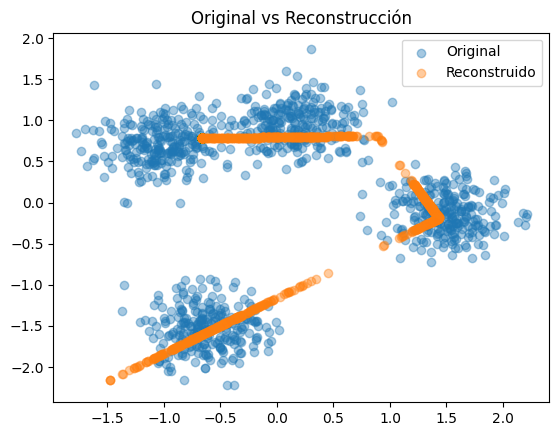

In [9]:
#Reconstrucción de datos
X_reconstructed = autoencoder.predict(X)

plt.scatter(X[:,0], X[:,1], label="Original", alpha=0.4)
plt.scatter(X_reconstructed[:,0], X_reconstructed[:,1],
            label="Reconstruido", alpha=0.4)
plt.legend()
plt.title("Original vs Reconstrucción")
plt.show()


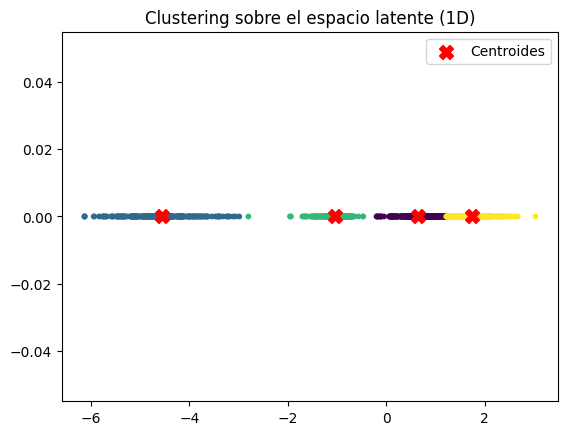

In [14]:
#Visualización del clustering

plt.scatter(
    X_latent[:,0], np.zeros_like(X_latent),
    c=clusters,
    cmap='viridis',
    s=10
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    np.zeros_like(kmeans.cluster_centers_),
    c='red',
    s=100,
    marker='X',
    label='Centroides'
)

plt.legend()
plt.title("Clustering sobre el espacio latente (1D)")
plt.show()

In [30]:
#Clustering en el espacio latente
kmeans = KMeans(n_clusters=4, random_state=42)
labels_latent = kmeans.fit_predict(X_latent)

X_labeled = np.hstack([X, labels_latent.reshape(-1,1)])

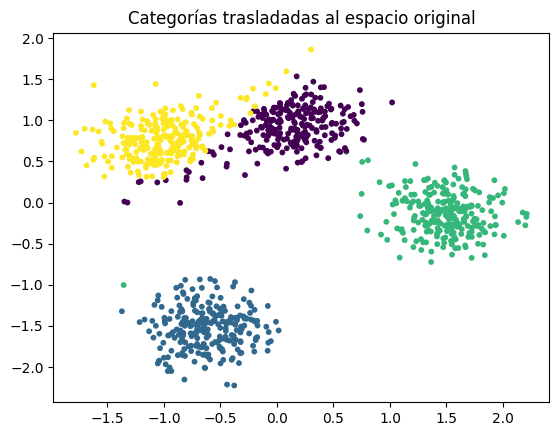

In [28]:
plt.scatter(
    X[:,0], X[:,1],
    c=labels_latent,
    cmap='viridis',
    s=10
)
plt.title("Categorías trasladadas al espacio original")
plt.show()


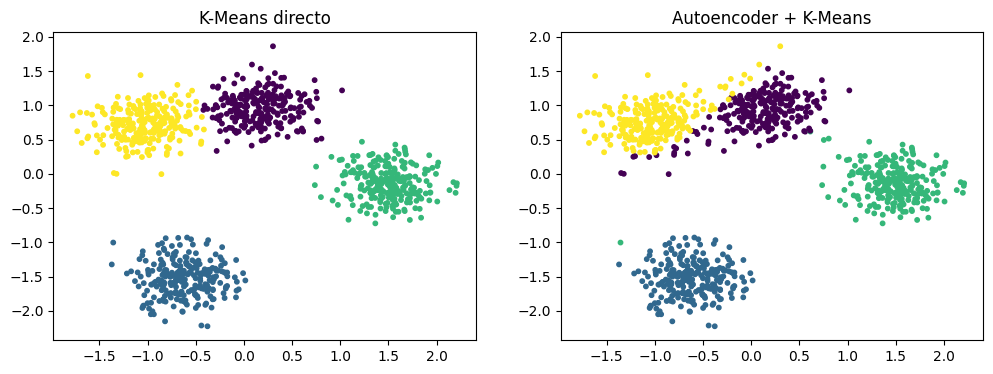

In [29]:
labels_raw = KMeans(n_clusters=4, random_state=42).fit_predict(X)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c=labels_raw, s=10)
plt.title("K-Means directo")

plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], c=labels_latent, s=10)
plt.title("Autoencoder + K-Means")

plt.show()
